Elastic Net Regression
**Goal:**
 1. Combine Ridge and Lasso Regularization
 2. Compare with Ridge and Lasso
 3. Observe coefficient shrinkage and feature selection

**Elastic Net = L1 + L2 Regularization**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
# creating synthetic data 
np.random.seed(42)

X = np.linspace(0, 10, 100)

y = (
    0.5 * X**3
    - 4 * X**2
    + 10 * X
    + np.random.randn(100) * 20
)

X = X.reshape(-1, 1)

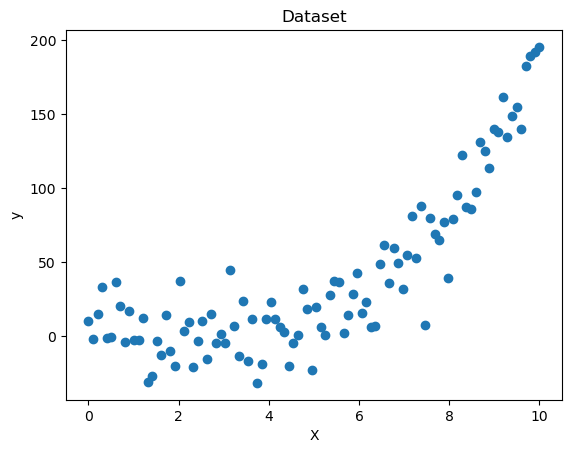

In [3]:
# Visualize data 
plt.scatter(X, y)

plt.title("Dataset")

plt.xlabel("X")
plt.ylabel("y")

plt.show()

In [4]:
# Polynomial features
poly = PolynomialFeatures(degree=10)

X_poly = poly.fit_transform(X)

print("Original Shape :", X.shape)
print("Polynomial Shape :", X_poly.shape)

Original Shape : (100, 1)
Polynomial Shape : (100, 11)


In [5]:
# Train test spilling
X_train, X_test, y_train, y_test = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)


In [6]:
# Rudge Regression
ridge = Ridge(alpha=10)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.49068e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [7]:
# Lasso Regression
lasso = Lasso(alpha=1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.327e+04, tolerance: 2.756e+01
  model = cd_fast.enet_coordinate_descent(


In [8]:
# Elastic net regression
elastic = ElasticNet(
    alpha=1,
    l1_ratio=0.5
)

elastic.fit(X_train, y_train)

elastic_pred = elastic.predict(X_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.322e+04, tolerance: 2.756e+01
  model = cd_fast.enet_coordinate_descent(


In [9]:
# Comparing R square
print("Ridge R2      :", r2_score(y_test, ridge_pred))
print("Lasso R2      :", r2_score(y_test, lasso_pred))
print("Elastic Net R2:", r2_score(y_test, elastic_pred))

Ridge R2      : 0.8586696993243917
Lasso R2      : 0.8686246489180309
Elastic Net R2: 0.8687899314945218


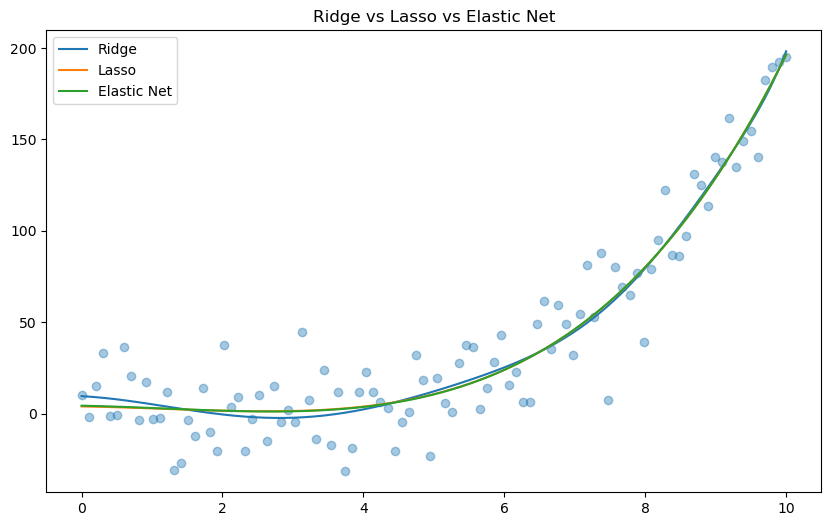

In [10]:
# Plotting learnt curve 
X_plot = np.linspace(0, 10, 500).reshape(-1, 1)

X_plot_poly = poly.transform(X_plot)

ridge_curve = ridge.predict(X_plot_poly)
lasso_curve = lasso.predict(X_plot_poly)
elastic_curve = elastic.predict(X_plot_poly)

plt.figure(figsize=(10,6))

plt.scatter(X, y, alpha=0.4)

plt.plot(X_plot, ridge_curve, label="Ridge")
plt.plot(X_plot, lasso_curve, label="Lasso")
plt.plot(X_plot, elastic_curve, label="Elastic Net")

plt.legend()

plt.title("Ridge vs Lasso vs Elastic Net")

plt.show()

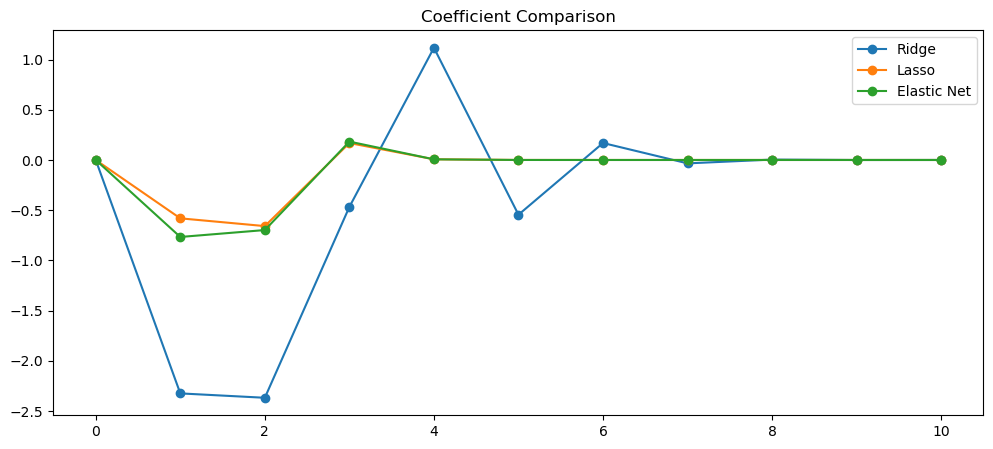

In [11]:
# Coefficients comparing 
plt.figure(figsize=(12,5))

plt.plot(ridge.coef_, marker='o', label='Ridge')
plt.plot(lasso.coef_, marker='o', label='Lasso')
plt.plot(elastic.coef_, marker='o', label='Elastic Net')

plt.legend()

plt.title("Coefficient Comparison")

plt.show()


In [12]:
print("Lasso Zero Coefficients :",
      np.sum(lasso.coef_ == 0))

print("Elastic Net Zero Coefficients :",
      np.sum(elastic.coef_ == 0))

Lasso Zero Coefficients : 1
Elastic Net Zero Coefficients : 1


## Observation

Ridge:
- Shrinks coefficients
- Keeps all features

Lasso:
- Shrinks coefficients
- Removes some features

Elastic Net:
- Combination of Ridge and Lasso
- Shrinks coefficients
- Can also remove features